<a href="https://colab.research.google.com/github/kazmi777999/Titanic-survival-analysis/blob/main/Titanic_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset shape:
(891, 15)

Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
  

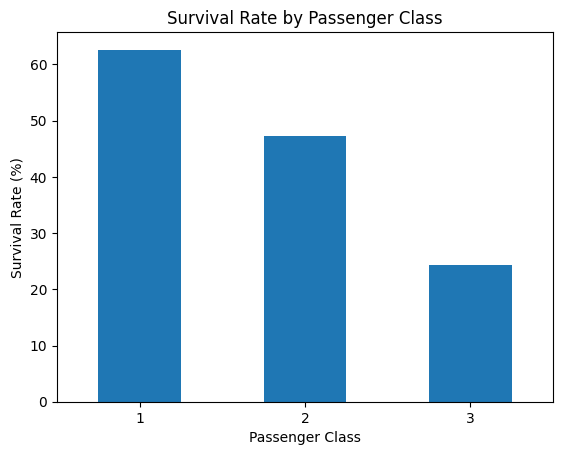

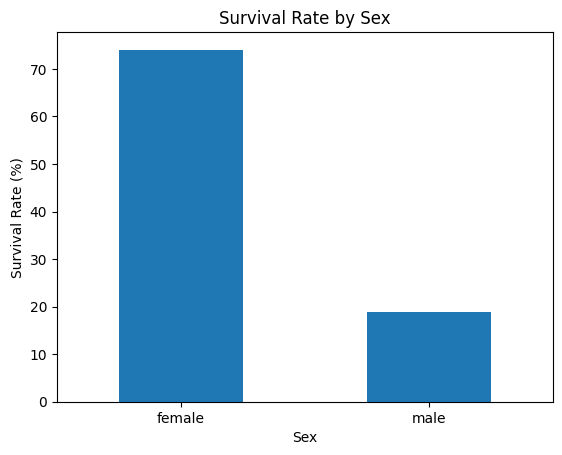

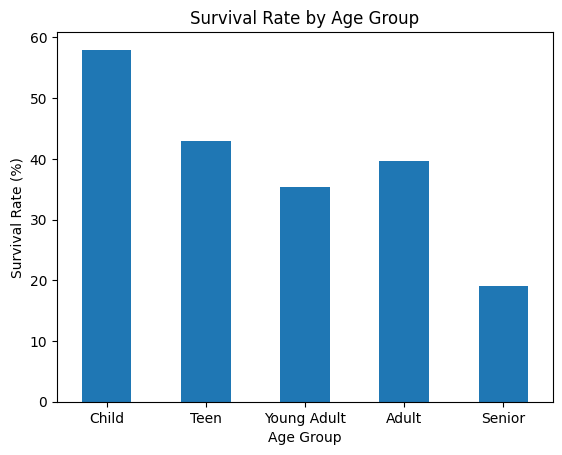

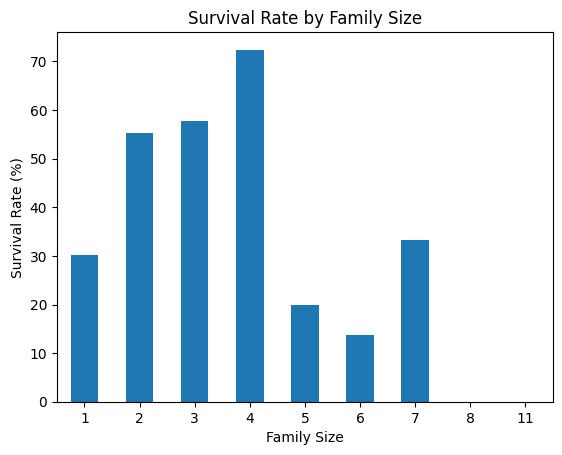

In [5]:
# Titanic Survival Analysis
# Project 2

import pandas as pd
import matplotlib.pyplot as plt



# 1. Load the dataset

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("First 5 rows:")
print(df.head())


# 2. Inspect the dataset

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset info:")
df.info()

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())



# 3. Clean the dataset
# Drop deck because most values are missing
df = df.drop(columns=["deck"])

# Fill missing age values with the median
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)

# Remove rows with missing embarked values
df = df.dropna(subset=["embarked"])

print("\nMissing values after cleaning:")
print(df.isna().sum())

print("\nShape after cleaning:")
print(df.shape)



# 4. Checkingg for duplicates


duplicate_count = df.duplicated().sum()

print("\nDuplicate-looking rows:")
print(duplicate_count)

# We are not removing them because the dataset
# does not contain a unique passenger ID.



# 5. Create new variables


# Create family size
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

print("\nFamily size preview:")
print(df[["sibsp", "parch", "family_size"]].head())

print("\nAge group preview:")
print(df[["age", "age_group"]].head())



# 6. Overall survival rate

survival_rate = df["survived"].mean() * 100

print(f"\nOverall Survival Rate: {survival_rate:.2f}%")

print("\nSurvival counts:")
print(df["survived"].value_counts())



# 7. Survival by passenger class


survival_by_class = df.groupby("pclass")["survived"].mean() * 100

print("\nSurvival Rate by Passenger Class:")
print(survival_by_class)


# -----------------------------
# 8. Survival by sex
# -----------------------------

survival_by_sex = df.groupby("sex")["survived"].mean() * 100

print("\nSurvival Rate by Sex:")
print(survival_by_sex)


# 9. Survival by age group


survival_by_age = (
    df.groupby("age_group", observed=True)["survived"]
    .mean() * 100
)

print("\nSurvival Rate by Age Group:")
print(survival_by_age)


# 10. Survival by family size


survival_by_family = (
    df.groupby("family_size")["survived"]
    .mean() * 100
)

print("\nSurvival Rate by Family Size:")
print(survival_by_family)



# 11. Visualization:
# Survival by passenger class


survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()



# 12. Visualization:
# Survival by sex


survival_by_sex.plot(kind="bar")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()



# 13. Visualization:
# Survival by age group


survival_by_age.plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()



# 14. Visualization:
# Survival by family size


survival_by_family.plot(kind="bar")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()



# Titanic Survival Analysis

## Project 2 - Data Analysis with Pandas

### Objective

The goal of this project is to analyze the Titanic passenger dataset and investigate which passenger characteristics were associated with survival.

This project includes:

- Data loading
- Data inspection
- Data cleaning
- Missing value handling
- Duplicate checking
- Feature engineering
- Data analysis
- Data visualization
- Conclusions